In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load the Raw Dataset

In [29]:
df = pd.read_csv('data/HeartDiseaseTrain-Test.csv')

In [30]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


## Check for missing values

In [31]:
df.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

## Distribution Plots

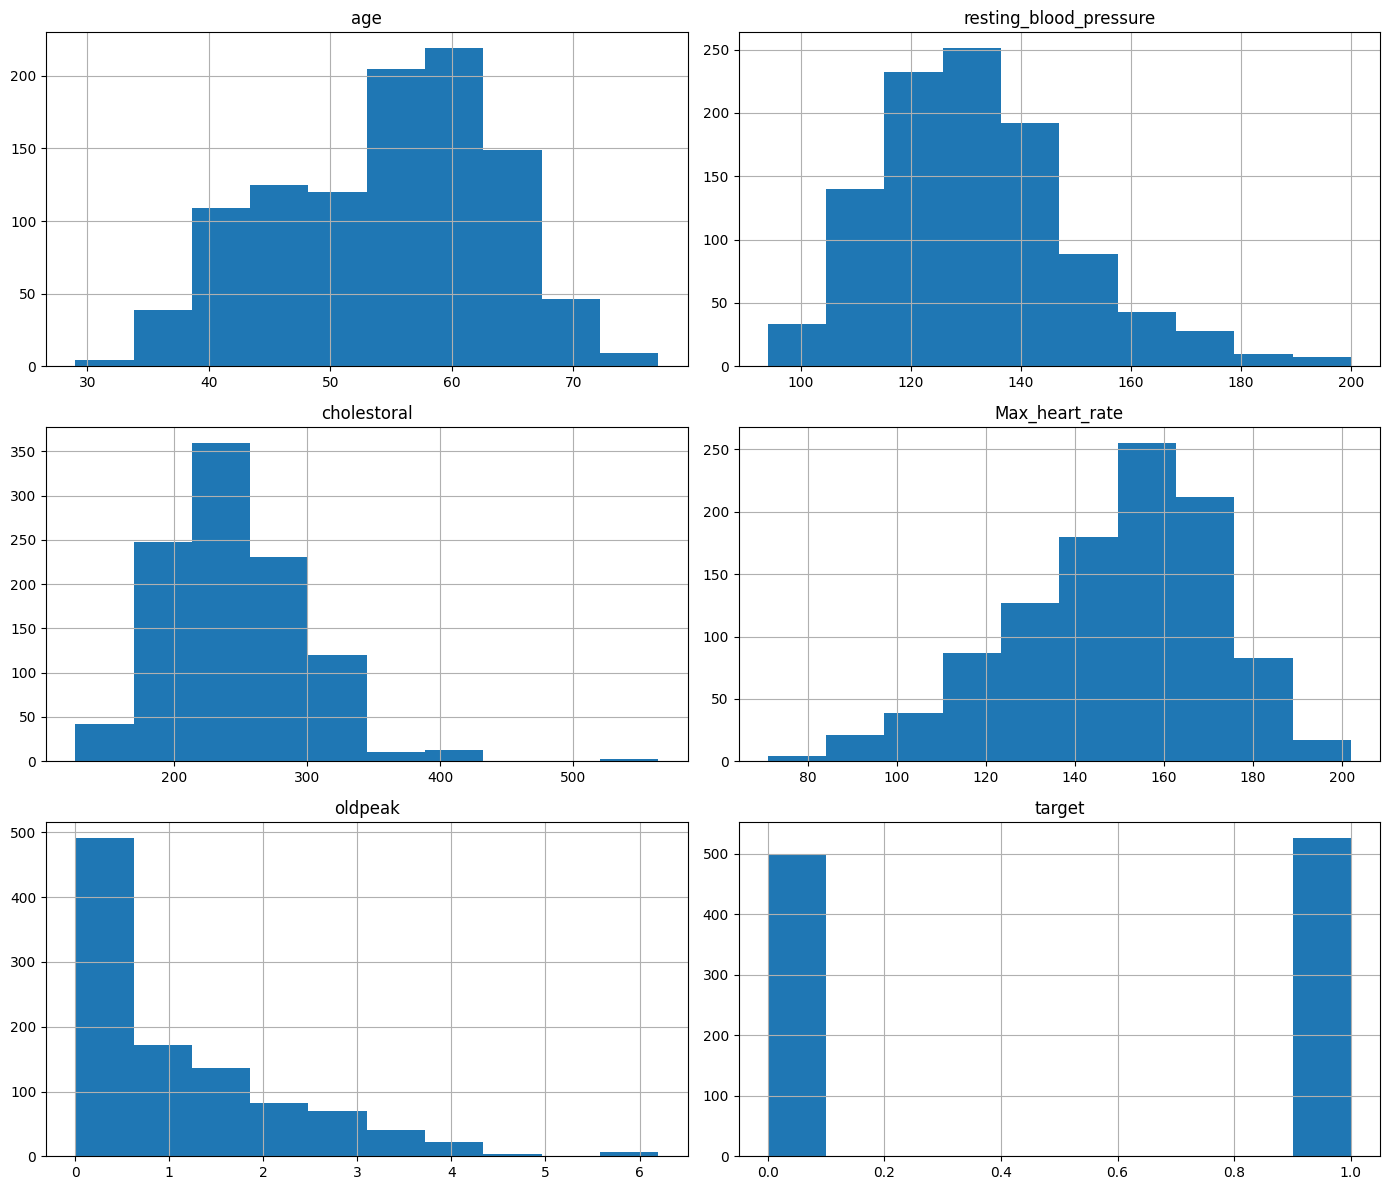

In [32]:
df.hist(figsize=(14,12))
plt.tight_layout()
plt.show()

## Outlier detection

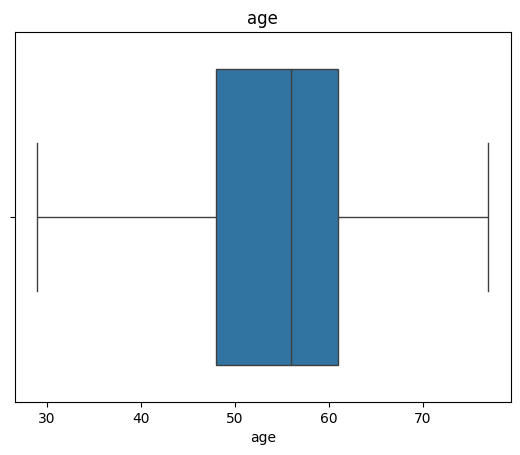

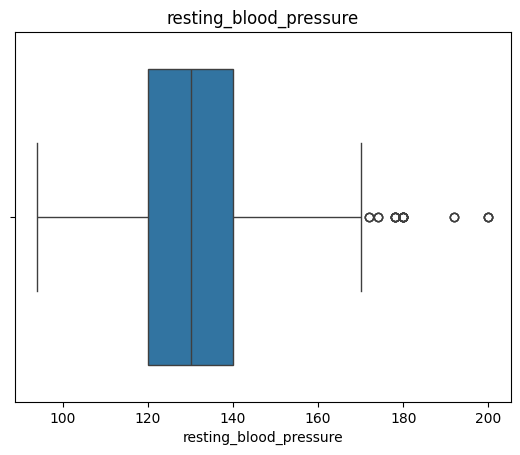

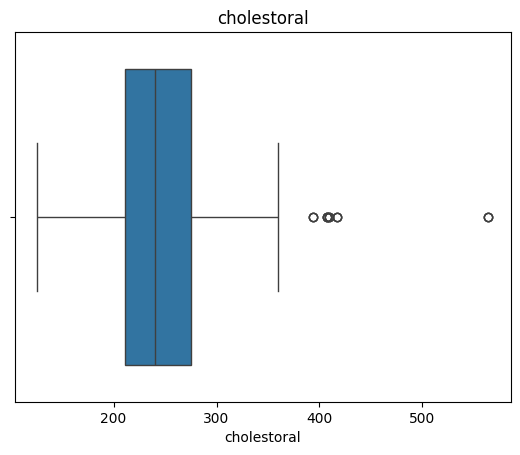

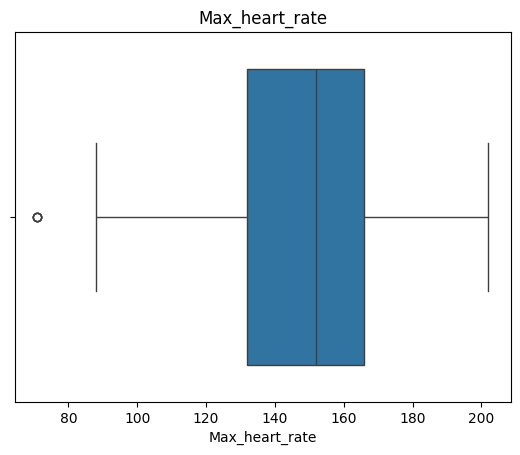

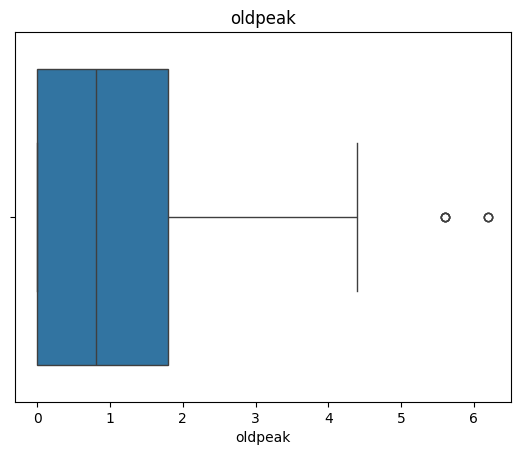

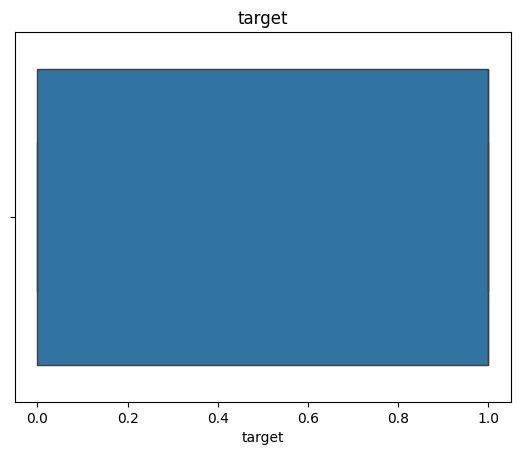

In [33]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Data Pre-processing

### Converting Non-numeric columns into Numeric columns

In [34]:
df_clean = df.copy()

In [35]:
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0,40,55,70,100], labels=['<40','40-55','55-70','70+'])

In [36]:
df_clean['high_chol'] = (df_clean['cholestoral'] > df_clean['cholestoral'].median()).astype(int)

In [37]:
df_clean['bp_high'] = (df_clean['resting_blood_pressure'] > df_clean['resting_blood_pressure'].median()).astype(int)

In [38]:
df_clean['chol_bp_interaction'] = df_clean['cholestoral'] * df_clean['resting_blood_pressure']

In [39]:
cat_cols = ['sex','chest_pain_type','fasting_blood_sugar','rest_ecg','exercise_induced_angina','slope','vessels_colored_by_flourosopy' ,'thalassemia']
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
df_clean = pd.get_dummies(df_clean, columns=['age_group'], drop_first=True)

In [40]:
df_clean.head()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target,high_chol,bp_high,chol_bp_interaction,sex_Male,...,vessels_colored_by_flourosopy_One,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect,age_group_40-55,age_group_55-70,age_group_70+
0,52,125,212,168,1.0,0,0,0,26500,True,...,False,False,True,False,False,False,True,True,False,False
1,53,140,203,155,3.1,0,0,1,28420,True,...,False,False,False,True,False,False,True,True,False,False
2,70,145,174,125,2.6,0,0,1,25230,True,...,False,False,False,True,False,False,True,False,True,False
3,61,148,203,161,0.0,0,0,1,30044,True,...,True,False,False,False,False,False,True,False,True,False
4,62,138,294,106,1.9,0,1,1,40572,False,...,False,True,False,False,False,False,False,False,True,False


## Correlation Heatmap

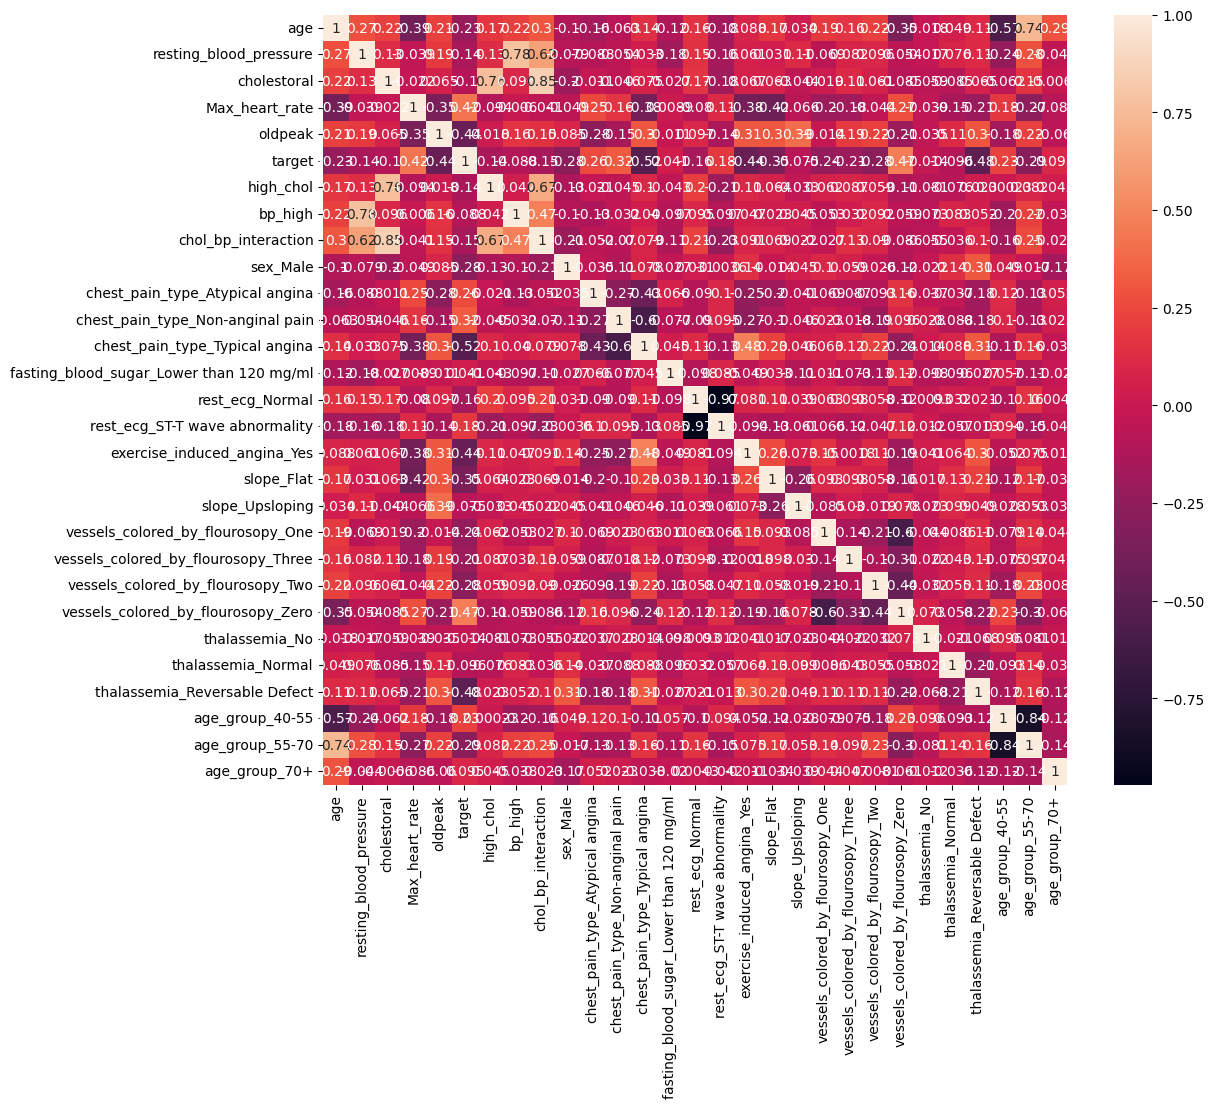

In [41]:
plt.figure(figsize=(12,10))
sns.heatmap(df_clean.corr(), annot=True)
plt.show()

## Remove highly correlated features

In [ ]:
corr_matrix = df_clean.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.9
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated features to drop:", to_drop)

df_clean = df_clean.drop(columns=to_drop)

Highly correlated features to drop: ['rest_ecg_ST-T wave abnormality']


: 

## Outlier Treatment

In [42]:
for col in df_clean.select_dtypes(include=np.number).columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = np.clip(df_clean[col], lower, upper)

In [43]:
df_clean.head()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target,high_chol,bp_high,chol_bp_interaction,sex_Male,...,vessels_colored_by_flourosopy_One,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect,age_group_40-55,age_group_55-70,age_group_70+
0,52,125,212,168,1.0,0,0,0,26500,True,...,False,False,True,False,False,False,True,True,False,False
1,53,140,203,155,3.1,0,0,1,28420,True,...,False,False,False,True,False,False,True,True,False,False
2,70,145,174,125,2.6,0,0,1,25230,True,...,False,False,False,True,False,False,True,False,True,False
3,61,148,203,161,0.0,0,0,1,30044,True,...,True,False,False,False,False,False,True,False,True,False
4,62,138,294,106,1.9,0,1,1,40572,False,...,False,True,False,False,False,False,False,False,True,False


In [44]:
df_clean.to_csv('data/cleaned_data.csv', index=False)
print('Saved cleaned_data.csv')

Saved cleaned_data.csv
